# Latent Variable Models
### `! git clone https://github.com/ds4e/logistic_regression`

## Introduction
- Linear models, especially with LASSO and Ridge, are one of our most powerful frameworks: We can manage complex feature spaces, and explain how the covariates/features determine the values of the predictions
- Linear models, however return a numeric value between $-\infty$ and $+\infty$, and we can't really restrict this further (e.g. probabilities between 0 and 1, count data with values like 0, 1, 2, ..., survival data with times greater than zero)
- But, we can extend the concept of linear models to accomodate this situation

## Motivating Example
- Remember our heart failure problem? `DEATH_EVENT=0` means the patient survived, and `DEATH_EVENT=1` means the patient died
- Let's make a quick linear model and take a look at the predictions it makes
- (We won't bother with the train-test split, because we're just playing with the linear model framework on this occasion)
- Since the linear model is predicting a binary outcome, we interpret its value as a probability

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
print(df.head())

y = df['DEATH_EVENT']
X = df.drop(['DEATH_EVENT', 'time'],axis=1)

reg = LinearRegression()
reg = reg.fit(X,y)
y_hat = reg.predict(X)

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

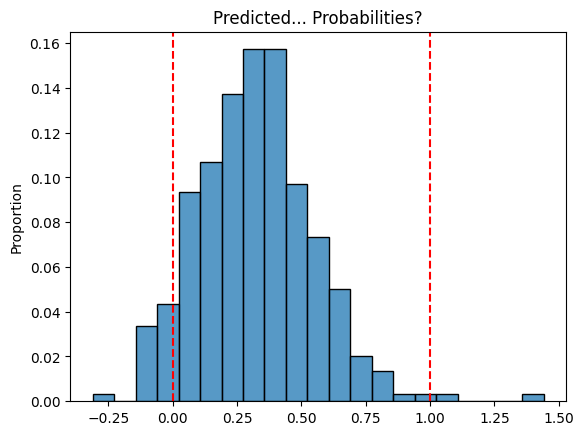

In [2]:
sns.histplot(y_hat,stat='proportion').set(title='Predicted... Probabilities?')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')

## Linear Probability Models
- There are a substantial number of outcomes below zero and above one. We can't interpret these as probabilities.
- If there are only a few violations not far below zero or above one, we might shrug and put up with it. The linear model is very explainable, easy to compute, and so on.
- But if we need this for clinical purposes, this many violations of these sizes suggests the linear model isn't always a good tool.
- Do we have another alternative?

## Linearity and Non-Linearity
- What does a "linear model" really mean, anyway? 
- If we take two linear models, multiple them by a scalar, and add, we get a linear model back:
$$
s m(x,b) + r m(x,b') = m(x, sb + r b')
$$
- If a function has this property, it must be a linear model of the form $m(x,b) = x \cdot b$
- But this kind of model doesn't place any meaningful restrictions on $\hat{y}$

## Latent Variable Models
- We like linear models, because they are interpretable
- We don't like linear models, because they can't accomodate reasonable restrictions on the outcomes
- Solution: Pass the **linear latent variable** $L_i = x_i \cdot b$ into an **activation function**, to get your prediction:
$$
\hat{y}_i = A(x_i \cdot b)
$$
- This is a non-linear model, unless $A(L)=L$
- You never observe $L_i$, which is why it is **latent**: You only observe the factors/covariates $x_i$ and the $y_i$, and the model matches the probabilties of the predicted outcomes to the distribution of observed outcomes as nearly as much as possible

## General Linear Models, in general
So we take our latent index over a carefully engineered feature space, and

1. If the outcome is binary 0/1, we use **logistic regression** to prediction a probability between 0 and 1 that the outcome is 1, $\hat{p}$
2. If the outcome is categorical, we use **multinomial logistic regression** or **softmax regression** to predict the probabilities of each label occurring, $(\hat{p}_1, \hat{p}_2, ... \hat{p}_L)$
3. If the outcome is a count like $0, 1, 2, ...$ we use **Poisson regression** to predict the probability that each non-negative integer value occurs, $(\hat{p}_0, \hat{p}_1, \hat{p}_2, ...)$

All of these methods can be used for classification instead of regression, and you report the most likely outcome as your classification

## Real non-linearity
- So now, our models are linear in the latent index because $s L + (1-r)L' = x \cdot (s b + rb')$, but they are not linear overall because of the activation function:
$$
s A(L) + r A(L') \neq A(x \cdot (s b + rb'))
$$
- This is one of the key observations that makes neural networks useful

## Outline

1. Logistic Regression (Binary Outcomes)
2. Multinomial Logistic Regression (Categorical Outcomes)

# 1. Logistic Regression (Binary Outcomes)

## Logistic Function/Distribution
- We often need a "nice" function that takes the "bell-curve" shape, but is easier to compute and work with than the normal distribution
- The **Logistic Distribution** is
$$
F(L) = \dfrac{e^{L}}{1+e^{L}},
$$
and has a density function
$$
f(L) = \dfrac{e^{L}}{(1+e^{L})^2} = F(L)(1-F(L))
$$
- This has the class S-shaped distribution, and bell-shaped density

In [3]:
from scipy.stats import norm

X = np.arange(-3.5, 3.5, 0.1)

pr_logit = np.exp(X) / (1 + np.exp(X))
pr_normal = norm.cdf(X)

pdf_logit = pr_logit * (1-pr_logit)
pdf_normal = norm.pdf(X)


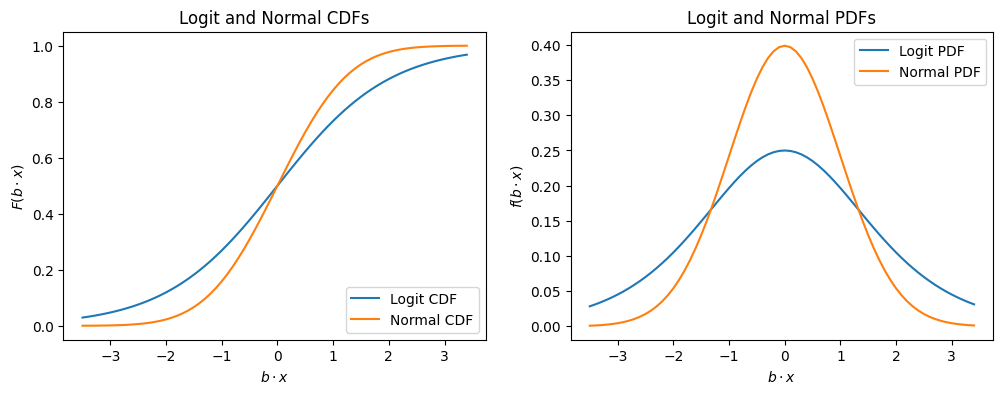

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: CDFs
axes[0].plot(X, pr_logit, label='Logit CDF')
axes[0].plot(X, pr_normal, label='Normal CDF')
axes[0].set_xlabel(r"$b \cdot x$")
axes[0].set_ylabel(r"$F(b \cdot x)$")
axes[0].set_title("Logit and Normal CDFs")
axes[0].legend(loc='lower right')

# Right panel: PDFs
axes[1].plot(X, pdf_logit, label='Logit PDF')
axes[1].plot(X, pdf_normal, label='Normal PDF')
axes[1].set_xlabel(r"$b \cdot x$")
axes[1].set_ylabel(r"$f(b \cdot x)$")
axes[1].set_title("Logit and Normal PDFs")
axes[1].legend(loc='upper right')

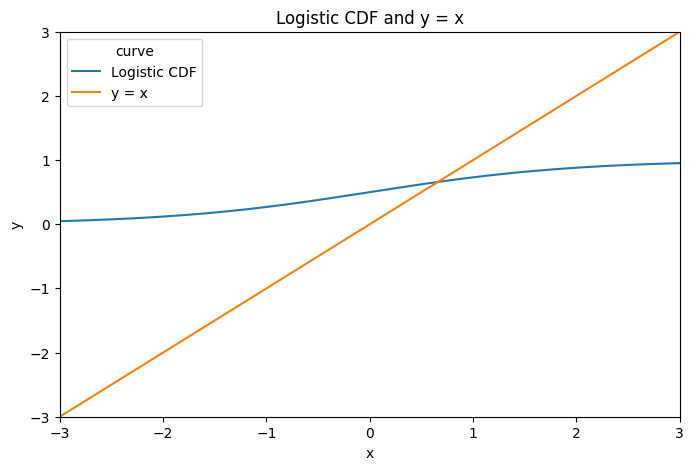

In [5]:
X = np.linspace(-3, 3, 200)
logistic_cdf = np.exp(X) / (1 + np.exp(X))

df = pd.DataFrame({
    "x": np.concatenate([X, X]),
    "y": np.concatenate([logistic_cdf, X]),
    "curve": ["Logistic CDF"] * len(X) + ["y = x"] * len(X),
})

plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="x", y="y", hue="curve")

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.title("Logistic CDF and y = x")
plt.show()

## Prediction with Logistic Regression
- With logistic distribution, we can plug $L_i = x_i \cdot b$ into $F(L)$, and we are guaranteed to get a probability back:\
**plug the x*b into the logisic function bc a linear function must have x*b and this will output a probability.**\
**- latent variable is x*b because it is not observed.**\
$$
\hat{p}_i = \frac{e^{x_i \cdot b}}{1+e^{x_i \cdot b}}
$$
- This is the probability that we observe $y_i = 1$, after observing $x_i$
- We are using $x_i$ to provide an estimate of the probability, a number, so this is regression

## Prediction with Logistic Classification
- If, instead, we "round" the output to 0 or 1, we are doing a classification exercise
- In this case, our prediction looks something more like
$$
\hat{\ell}_i = \begin{cases}
0, & \frac{e^{x_i \cdot b}}{1+e^{x_i \cdot b}} < .5 \\
1, & \frac{e^{x_i \cdot b}}{1+e^{x_i \cdot b}} \ge .5.
\end{cases}
$$
- Here, the output of our model is a hard classification as class 0 or class 1, rather than a number between 0 and 1
- Later, we'll move that .5 threshold around, and that becomes one of our ways of probing the performance of a classifier

## Logistic Model as Neural Network
- Imagine $L_i = x_i \cdot b$ as a stimulus hitting a neuron. 
- If the stimulus is very negative, the neuron is unlikely to fire, because
$$
\dfrac{e^{L}}{1+e^{L}}
$$
is close to zero
- If the stimulus is very positive, the neuron is likely to fire, because
$$
\dfrac{e^{L}}{1+e^{L}}
$$
is close to 1
- If we start wiring together units of the form $A(b + w \cdot z)$, we get artifical neural networks

- **A neural network is a bunch of logistic regressions wired together.**

<img src="./src/neuron.png" alt="Illustration of logistic regression as a neuron firing." width="85%" height="auto">

## How to Fit A Logistic Regression Model
- You could compute the SSE of the predicted probabilities from the observed outcomes: This is called the **Brier Score**. That is not what most people do.
- Instead, we ask, "What is the probability of observing these data, given $b$?" That is the **likelihood function**
- We then pick the $b$ that maximizes the likelihood function; this is called **maximum likelihood estimation**
- It is like a reductio ad absurdum argument, but probabilistic.
- Then the probability of observing these $y$ given $x$ and $b$ is given by the **likelihood function**,
$$ pr[y|x,b] = \prod_{i =1}^N \left(\dfrac{\exp(b \cdot x_i)}{1+\exp(b \cdot x_i)}\right)^{y_i} \times  \left(  \dfrac{1}{1+\exp(b \cdot x_i)}\right)^{1-y_i}$$
- This is called **maximum likelihood estimation**, and is an alternative way to approach the problem of picking parameters $b$ to fit a model to data that has excellent statistical properties

## Binary Cross Entropy
- Because the likelihood function is a product of probabilities, we typically take the natural logarithm to convert the product into a sum; since the log function is increasing, the two problems have the same solution (right?)
- The **log likelihood**, which statistics people want to maximize, is
$$
\ell \ell(b) = \sum_{i=1}^N y_i \log \left( \hat{p}_i(b) \right) + (1-y_i) \log \left( 1-\hat{p}_i(b) \right) 
$$
and the **binary cross entropy**, which CS people want to minimize, is
$$
\text{bce}(b) = - \sum_{i=1}^N y_i \log \left( \hat{p}_i(b) \right) + (1-y_i) \log \left( 1-\hat{p}_i(b) \right) 
$$
- These problems have the same solution, it's just which community is writing the model down

## SciKit
- Scikit, of course, has a package for all this:
    - `from sklearn.linear_model import LogisticRegression`
- It happens that **SciKit logistic regression is not logistic regression**. **You must add an option,`penalty=None`, to get vanilla logistic regression and not the regularized Ridge/L2 version.**
- Logistic regression also has a `fit_intercept` option to handle the dummy variable trap, just like linear regression
- When using SciKit for nonlinear models, **min-max scale your numeric variables**; otherwise the numerical solver can become unstable
- For a fitted model, you can use it for regression or classification:
    - `reg.predict(X)` will return a hard class label, 0 or 1, for classification
    - `reg.predict_probab(X)` will return probabilities between 0 and 1, for regression

## Numerical Analysis
- With linear regression, we derived the general concept that $\hat{b} = (X^{\top}X)^{-1} X^{\top}y \approx \text{cov}(X,y)/\text{var(X)}$
- With non-linear models like logistic regression, we cannot solve the model this way, except for the simplest of special cases
- Instead, we use **gradient descent**: Starting from an initial guess of $b$, we compute the **gradient** of the binary cross entropy, and take steps in the direction in which the value of the BCE falls the fastest
- You should take a whole class on numerical optimization, it's a great subject

## Interpreting the Coefficients
- I don't think you should, beyond "Positive means more likely, negative means less likely."
- Some people interpret these values in terms of Log-Odds; I guess people can get used to anything
- The problem is that, in non-linear models, changes in $x$ don't impact changes in $y$ in proportion to $b$ anymore
- Reporting the Marginal Effect at the Mean or the Mean Marginal Effect would be superior, but let's not get distracted

## Example
- Let's return to predicting DEATH EVENTS with logistic regression and logistic classification

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
print(df.head())

y = df['DEATH_EVENT']
X = df.drop(['DEATH_EVENT', 'time'],axis=1)

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [7]:
reg = LogisticRegression(penalty=None,
                         max_iter=5000)
reg = reg.fit(X,y)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [8]:
pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

,Variable,Coefficient
0,age,5.729941e-02
1,anaemia,4.023742e-01
2,creatinine_phosphokinase,2.805456e-04
3,diabetes,2.003219e-01
4,ejection_fraction,-7.081526e-02
5,high_blood_pressure,4.559784e-01
6,platelets,-6.380802e-07
7,serum_creatinine,6.994706e-01
8,serum_sodium,-2.233646e-02
9,sex,-3.066621e-01


**In a linear regression, the coefficients are correlated with the chance of heart failure. But not in logistic**

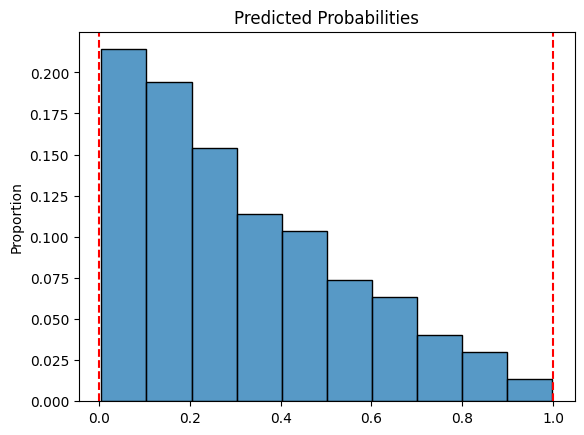

In [9]:
# Regression
y_reg = reg.predict_proba(X)
y_reg = [ row[1] for row in y_reg ] # Life is suffering

sns.histplot(y_reg,stat='proportion').set(title='Predicted Probabilities')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')

In [10]:
# Classification
y_class = pd.Series( reg.predict(X) )

tab = pd.crosstab( y_class, df['DEATH_EVENT'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')


Confusion matrix:
 DEATH_EVENT    0   1
row_0               
0            182  50
1             21  46

Accuracy: 0.7625418060200669


- How does linear regression perform?

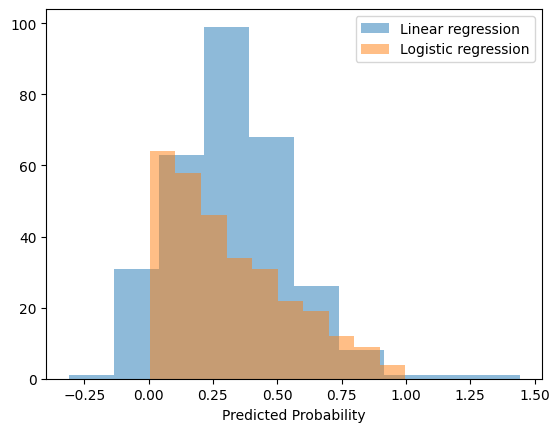

In [11]:
plt.hist(x=y_hat, alpha = 0.5, label='Linear regression')
plt.hist(x=y_reg, alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show() 

## Exercise
- Predicting default before a loan is extended or identifying borrowers who are exhibiting signs of distress is common in banking and finance
- There are a variety of laws that regulate how this must be done (In the U.S.: Equal Credit Opportunity Act, Fair Housing Act)
- We have a dataset from Brazil where we can play with the data to see how logistic regression and linear regression compare
- Open the `brazil_codebook.XLS` file and look at the data documentation, then use `brazil_default.csv` to predict which borrowers default
- When you have a logistic regression model finished, compare your results to linear regression

# 2. Multinomial Logistic Regression (Categorical Outcomes)

## General Categorical Outcomes
- So we have linear regression for a numerical response, $y = x \cdot b$
- We have logistic regression for a dummy or binary response, $\hat{p} = e^{x\cdot b}/(1+e^{x\cdot b})$
- Is there an option for multi-label categorical responses? So if there are labels $\ell$, like `zebra` or `honda`, we can predict those from a latent variable?
- The generalization of logistic regression to $>2$ outcomes is called **multinomial logistic regression**

### Softmax / Multiclass Logistic Structure

    x.        
  / | \           
 0  1  2       

From node **x**, there are three classes: 0, 1, and 2.

- Class 0:
$$
\frac{1}{1 + e^{x \beta_1} + e^{x \beta_2}}
$$

- Class 1:
$$
\frac{e^{x \beta_1}}{1 + e^{x \beta_1} + e^{x \beta_2}}
$$

- Class 2:
$$
\frac{e^{x \beta_2}}{1 + e^{x \beta_1} + e^{x \beta_2}}
$$


## Multinomial Logit
- If you have more than two discrete outcomes, you can still use a logistic model, unlike the Linear Probability Model
- For each outcome $k=1,...,K$, you have a latent variable $L_{ik} = \beta_k \cdot x_i + \varepsilon_{ik}$
- Imagine you, $i$, deciding which make/model of a car $k$ to buy, or which ready-to-eat cereal $k$ to purchase: $L_{ik}$ is roughly how much you liked option $k$, which isn't observed. We only observe what you actually picked.
- The outcome is the maximum value over all the latent indices $(L_{i1}, L_{i2}, ..., L_{iK})$: 
$$
y_{ik} = \begin{cases}
1, & \quad  L_{ik} > L_{ij}, j \neq k\\
0, & \quad \text{otherwise.}
\end{cases}
$$
- So for each observation $i$ and outcome $k$, we just observe whether $i$ chose $k$ or not, and not the latent indices $L_{ik}$
- We want to recover the underlying mean preferences, the $\beta_1, ..., \beta_K$ coefficients

## Multinomial Logit
- You can show that
$$ pr[y_{ik} = 1] = \begin{cases}
\dfrac{e^{\beta_k \cdot x_i}}{1+\sum_{j=1}^{K-1} e^{\beta_j \cdot x_i}}, & \quad k<K\\
\dfrac{1}{1+\sum_{j=1}^{K-1} e^{\beta_j \cdot x_i}}, & \quad k = K
\end{cases}
$$
and fit the model using maximum likelihood,
$$L(\beta_1, \beta_2, ..., \beta_{K-1}) = \prod_{i = 1}^{N} \left( \dfrac{e^{\beta_1 \cdot x_i}}{1+\sum_{j=1}^{K-1} e^{\beta_j \cdot x_i}} \right)^{y_{i1}} \left( \dfrac{e^{\beta_2 \cdot x_i}}{1+\sum_{j=1}^{K-1} e^{\beta_j \cdot x_i}} \right)^{y_{i2}} \cdot \cdot \cdot \left( \dfrac{e^{\beta_{K-1} \cdot x_i}}{ 1+\sum_{j=1}^{K-1} e^{\beta_j \cdot x_i}}\right)^{y_{i,K-1}}
$$
- This is popular in marketing and the kind of model you should be "afraid" of, in the sense that we can use information about people $x_i$ to pick parameters $b$ and pick profit-maximizing prices

## Categorical Cross Entropy
- That likelihood looks nasty: Stats people take logs, and instead maximize the log likelihood,
$$
\ell \ell(b) = \frac{1}{N} \sum_{i=1}^N \sum_{k=1}^{K-1} y_{ik} \log( \hat{p}_{ik})
$$
while CS people minimize the categorical cross entropy,
$$
\text{cce}(b) = - \dfrac{1}{N} \sum_{i=1}^N \sum_{k=1}^{K-1} y_{ik} \log( \hat{p}_{ik})
$$
- The intuition is that the misclassification error is determined by the true class label for each observation $i$, $y_{ik}$, and the further $\hat{p}_{ik}$ is from 1, the bigger the loss will be 


## Example: Landmines
- There are five kinds of landmines, which must be disarmed in different ways
- There are three predictor/feature/covariates available: voltage, height, and soil
- We want to build a model to predictive model to aid people in decision-making when facing these devices

In [12]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

mdf = pd.read_csv('./data/land_mines.csv') # landmine data

## Data for sklearn
y_mines = mdf['mine_type']
X_mines = mdf.drop('mine_type',axis=1)


In [13]:
## Run Logistic Regression
mnl = LogisticRegression(penalty=None).fit(X_mines,y_mines)

## Regression coefficients
mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_,axis=1)
print('Coefficients for each landmine type:')
mnl_coef

Coefficients for each landmine type:


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,voltage,height,soil
0,-27.160473,-4.217283,1.008841
1,37.249504,9.236162,-2.769627
2,3.838236,-0.407835,0.267611
3,-11.667221,-3.071488,0.833919
4,-2.260045,-1.539557,0.659257


In [14]:
pd.DataFrame(mnl.predict_proba(X_mines)) # For each landmine, what's the probability of each type?

,0,1,2,3,4
0,0.452967,0.000009,0.066211,0.346619,0.134195
1,0.456547,0.000031,0.076554,0.325986,0.140882
2,0.577952,0.000016,0.048908,0.273674,0.099450
3,0.641892,0.000028,0.041890,0.232563,0.083627
4,0.570119,0.000129,0.064459,0.253743,0.111550
...,...,...,...,...,...
333,0.139971,0.045524,0.305945,0.224695,0.283866
334,0.073745,0.000336,0.274076,0.301256,0.350587
335,0.247693,0.000129,0.156706,0.339611,0.255861
336,0.121238,0.004442,0.287099,0.261459,0.325763


In [15]:
pd.crosstab( y_mines, mnl.predict(X_mines)) # Confusion Matrix

col_0,1,2,3,4,5
mine_type,,,,,
1,60,0,2,7,2
2,0,62,8,0,0
3,3,3,31,16,13
4,21,2,21,8,14
5,7,0,25,18,15


In [16]:
tab = pd.crosstab( y_mines, mnl.predict(X_mines)) 
acc = np.trace(tab)/len(y_mines) # Accuracy
print('Accuracy: ', acc)

Accuracy:  0.5207100591715976


## Exercise
- Corporate bonds are rated from D to C to B to A, like academic grades
- Instead of +/-, they typically do AAA>AA>A
- The `corporate_ratings.csv` dataset has `Rating` for a variety of companies, along with various statistics about the company (profit margin, cash ratio, etc.)
- Create a rich feature space, use L2 or L1 regularization, and create a model that takes corporation statistics and predicts bond rating

# Conclusion

## Regularization
- Scikit **automatically** applies Ridge/$L2$ regularization to logistic and multinomial logistic regression, with `penalty=l2`
- To turn it off, if you wish, set `penalty=None`
- If you prefer LASSO/$L1$ regularization, set `penalty=l1`
- So all of our ideas about feature spaces apply here: We **need** interactions and powers and one-hot encodings and transformations of our variables, to get our models to work. Just dumping the raw data into the woodchipper is not going to perform well
- Scikit does not implement regularization for Poisson Regression, so you either have to do it yourself or use `StatsModels` or `glmnet`

## Neural Networks and Deep Learning
- Roughly speaking, the **multilayer perception** has an **output layer** that looks exactly like linear regression, logistic regression, or multinomial logistic regression
- But instead of raw features $x$, hidden values of latent variables are passed into the final layer
- We work backwards through hidden layers, wired up with weights from hidden latent variable to hidden latent variable, passing through a logistic-type function between each layer
- There is an input layer, $x$, that represents the raw data
- The goal of deep learning is to learn how to do the feature engineering without artisanal hand-crafted feature spaces: It is learning how to represent the data, or how to do **representation learning**

## Conclusion
- So for "any" kind of response (numeric, binary, categorical, count), you now have a powerful framework for making predictions
- The key is the idea of a latent index: All of the work and 
- Scikit 

## In Class Practice

In [ ]:
import pandas as pd
bf = pd.read_csv("data/brazil_default.csv",  encoding="latin1")
print(bf.head())

codebook = pd.read_excel("data/brazil_codebook.xls")
codebook[0:60]

   ID_CLIENT CLERK_TYPE  PAYMENT_DAY APPLICATION_SUBMISSION_TYPE  \
0          1          C            5                         Web   
1          2          C           15                       Carga   
2          3          C            5                         Web   
3          4          C           20                         Web   
4          5          C           10                         Web   

   QUANT_ADDITIONAL_CARDS  POSTAL_ADDRESS_TYPE SEX  MARITAL_STATUS  \
0                       0                    1   F               6   
1                       0                    1   F               2   
2                       0                    1   F               2   
3                       0                    1   F               2   
4                       0                    1   M               2   

   QUANT_DEPENDANTS  EDUCATION_LEVEL  ... FLAG_HOME_ADDRESS_DOCUMENT FLAG_RG  \
0                 1                0  ...                          0       0   
1         

/var/folders/p6/ndfyjpv90zq65rdw9rykcplc0000gn/T/ipykernel_25693/1798188246.py:2: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  bf = pd.read_csv("data/brazil_default.csv",  encoding="latin1")


,Var_Id,Var_Title,Var_Description,Field_Content
0,1,ID_CLIENT,Sequential number for the applicant (to be use...,"1-50000, 50001-70000, 70001-90000"
1,2,CLERK_TYPE,Not informed,C
2,3,PAYMENT_DAY,"Day of the month for bill payment, chosen by t...","1,5,10,15,20,25"
3,4,APPLICATION_SUBMISSION_TYPE,Indicates if the application was submitted via...,"Web, Carga"
4,5,QUANT_ADDITIONAL_CARDS,Quantity of additional cards asked for in the ...,"1,2,NULL"
5,6,POSTAL_ADDRESS_TYPE,Indicates if the address for posting is the ho...,1.2
6,7,SEX,NaN,"M=Male, F=Female"
7,8,MARITAL_STATUS,Encoding not informed,"1,2,3,4,5,6,7"
8,9,QUANT_DEPENDANTS,NaN,"0, 1, 2, ..."
9,10,EDUCATION_LEVEL,Edducational level in gradual order not informed,"1,2,3,4,5"


In [ ]:
vars = bf["QUANT_DEPENDANTS", "MONTHS_IN_RESIDENCE",'FLAG_AMERICAN_EXPRESS', 'FLAG_OTHER_CARDS', 'QUANT_BANKING_ACCOUNTS',
       'QUANT_SPECIAL_BANKING_ACCOUNTS', 'PERSONAL_ASSETS_VALUE', 'QUANT_CARS',
       'COMPANY', 'PROFESSIONAL_STATE', 'PROFESSIONAL_CITY',
       'PROFESSIONAL_BOROUGH', 'FLAG_PROFESSIONAL_PHONE',
       'PROFESSIONAL_PHONE_AREA_CODE', 'MONTHS_IN_THE_JOB']

yB = bf['TARGET_LABEL_BAD=1']
XB = bf.drop(["FLAG_MOBILE_PHONE", "TARGET_LABEL_BAD=1"], axis = 1)
def minmax(z):
    u = (z - min(z))/(max(z) - min(z))
    return u

    
reg = LogisticRegression(penalty=None,
                         max_iter=5000)
reg = reg.fit(X,y)

KeyError: ('QUANT_DEPENDANTS', 'MONTHS_IN_RESIDENCE', 'FLAG_AMERICAN_EXPRESS', 'FLAG_OTHER_CARDS', 'QUANT_BANKING_ACCOUNTS', 'QUANT_SPECIAL_BANKING_ACCOUNTS', 'PERSONAL_ASSETS_VALUE', 'QUANT_CARS', 'COMPANY', 'PROFESSIONAL_STATE', 'PROFESSIONAL_CITY', 'PROFESSIONAL_BOROUGH', 'FLAG_PROFESSIONAL_PHONE', 'PROFESSIONAL_PHONE_AREA_CODE', 'MONTHS_IN_THE_JOB')

In [32]:
bf.columns

Index(['ID_CLIENT', 'CLERK_TYPE', 'PAYMENT_DAY', 'APPLICATION_SUBMISSION_TYPE',
       'QUANT_ADDITIONAL_CARDS', 'POSTAL_ADDRESS_TYPE', 'SEX',
       'MARITAL_STATUS', 'QUANT_DEPENDANTS', 'EDUCATION_LEVEL',
       'STATE_OF_BIRTH', 'CITY_OF_BIRTH', 'NACIONALITY', 'RESIDENCIAL_STATE',
       'RESIDENCIAL_CITY', 'RESIDENCIAL_BOROUGH', 'FLAG_RESIDENCIAL_PHONE',
       'RESIDENCIAL_PHONE_AREA_CODE', 'RESIDENCE_TYPE', 'MONTHS_IN_RESIDENCE',
       'FLAG_MOBILE_PHONE', 'FLAG_EMAIL', 'PERSONAL_MONTHLY_INCOME',
       'OTHER_INCOMES', 'FLAG_VISA', 'FLAG_MASTERCARD', 'FLAG_DINERS',
       'FLAG_AMERICAN_EXPRESS', 'FLAG_OTHER_CARDS', 'QUANT_BANKING_ACCOUNTS',
       'QUANT_SPECIAL_BANKING_ACCOUNTS', 'PERSONAL_ASSETS_VALUE', 'QUANT_CARS',
       'COMPANY', 'PROFESSIONAL_STATE', 'PROFESSIONAL_CITY',
       'PROFESSIONAL_BOROUGH', 'FLAG_PROFESSIONAL_PHONE',
       'PROFESSIONAL_PHONE_AREA_CODE', 'MONTHS_IN_THE_JOB', 'PROFESSION_CODE',
       'OCCUPATION_TYPE', 'MATE_PROFESSION_CODE', 'EDUCATION_LEV